## Set Up

In [ ]:
!pip install -U bitsandbytes datasets transformers accelerate peft trl evaluate rouge_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Convenience variable so we don't repeat this path everywhere
DRIVE_DIR = "/content/drive/MyDrive/242B Group Project"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
os.environ["PYTHONUTF8"] = "1"
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer
from huggingface_hub import login
import torch
import evaluate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [5]:
from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_Llama'))

In [6]:
# train_data = pd.read_csv("/content/training_data.csv")
train_data_train = pd.read_csv(f"{DRIVE_DIR}/training_data_train.csv")
train_data_test = pd.read_csv(f"{DRIVE_DIR}/training_data_test.csv")
display(train_data_train.head(3))

,video_id,segment_index,n_segments,timestamp_start,timestamp_end,input,target_sentence,target_caption
0,v_QEdbqJijx1w,0,3,0.00,14.49,[0.0s] a woman sitting in front of a laptop co...,A woman is seen speaking to the camera while s...,A woman is seen speaking to the camera while s...
1,v_QEdbqJijx1w,1,3,15.25,44.61,[15.2s] a woman is sitting in front of a mirro...,She then holds up a contact lens and puts one ...,A woman is seen speaking to the camera while s...
2,v_QEdbqJijx1w,2,3,38.13,75.87,[38.1s] a woman in a black dress sitting at a ...,She puts another contact in her eye and smiles...,A woman is seen speaking to the camera while s...


In [7]:
print("Train data columns : " ,  train_data_train.columns)
print("Train data train shape : " ,  train_data_train.shape)
print("Train data test shape : " ,  train_data_test.shape)
# print("Train data shape : " ,  train_data.shape)

Train data columns :  Index(['video_id', 'segment_index', 'n_segments', 'timestamp_start',
       'timestamp_end', 'input', 'target_sentence', 'target_caption'],
      dtype='object')
Train data train shape :  (1196, 8)
Train data test shape :  (309, 8)


## Qwen model training

In [ ]:
# # Format the prompt using specific columns
# def format_instruction(row):
#     # We wrap the 'input' and 'target_caption' in a consistent instruction template
#     prompt = (
#         "Below is a sequence of frame descriptions from a video. "
#         "Write a cohesive caption summarizing the action.\n\n"
#         f"### Descriptions:\n{row['input']}\n\n"
#         f"### Caption:\n{row['target_caption']}"
#     )
#     return prompt
# df_train = train_data_train.copy()
# df_train['text'] = df_train.apply(format_instruction, axis=1)
# train_dataset = Dataset.from_pandas(df_train[['text']])


In [ ]:
# import torch
# import gc
# from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
# from trl import SFTConfig, SFTTrainer

# # --- CLEAR MEMORY ---
# gc.collect()
# torch.cuda.empty_cache()
# # ---------------------

# model_id = "Qwen/Qwen2.5-7B-Instruct"

# # ---------------------------------------------------------
# # 1. LOAD THE BASE MODEL
# # ---------------------------------------------------------
# print("Loading Base Model...")
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.float16
# )

# tokenizer = AutoTokenizer.from_pretrained(model_id)
# tokenizer.pad_token = tokenizer.eos_token
# tokenizer.padding_side = "right"

# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     quantization_config=bnb_config,
#     torch_dtype=torch.float16,
#     device_map={"": 0}           # Safely forces model onto T4 GPU
# )

# model.gradient_checkpointing_enable()
# model = prepare_model_for_kbit_training(model)

# # ---------------------------------------------------------
# # 2. ATTACH THE ADAPTERS & CAST
# # ---------------------------------------------------------
# print("Attaching LoRA Adapters...")
# peft_config = LoraConfig(
#     r=16,
#     lora_alpha=32,
#     lora_dropout=0.05,
#     bias="none",
#     task_type="CAUSAL_LM",
#     target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
# )

# model = get_peft_model(model, peft_config)

# # The ultimate safety net: force all trainable weights to standard float32
# for name, param in model.named_parameters():
#     if param.requires_grad:
#         param.data = param.data.to(torch.float32)



In [ ]:
# # ---------------------------------------------------------
# # 3. CONFIGURE AND START TRAINING
# # ---------------------------------------------------------
# print("Preparing Trainer...")
# training_args = SFTConfig(
#     output_dir="./video_caption_checkpoints",
#     per_device_train_batch_size=4,
#     gradient_accumulation_steps=4,
#     learning_rate=1e-4,
#     num_train_epochs=3,
#     logging_steps=10,
#     optim="paged_adamw_32bit",
#     save_strategy="epoch",
#     bf16=False,
#     fp16=False,
#     report_to="none",
#     dataset_text_field="text",
#     max_length=512               # <--- THE FINAL FIX: Renamed from max_seq_length!
# )

# trainer = SFTTrainer(
#     model=model,
#     train_dataset=train_dataset,
#     args=training_args,
# )


# print("Starting training! Let's go!")
# trainer.train()

Preparing Trainer...


Adding EOS to train dataset:   0%|          | 0/1196 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1196 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting training! Let's go!


Step,Training Loss
10,2.385292
20,1.805945
30,1.591539
40,1.427913
50,1.421045
60,1.412379
70,1.324841
80,1.354180
90,1.376378
100,1.337282


TrainOutput(global_step=225, training_loss=1.3873908763461642, metrics={'train_runtime': 3684.6568, 'train_samples_per_second': 0.974, 'train_steps_per_second': 0.061, 'total_flos': 3.61719572315136e+16, 'train_loss': 1.3873908763461642})

Saving Qwen + LORA trained model so we can use it later

In [ ]:
# trainer.save_model("./video_caption_model")

In [ ]:
# tokenizer.save_pretrained("./video_caption_model")

('./video_caption_model/tokenizer_config.json',
 './video_caption_model/chat_template.jinja',
 './video_caption_model/tokenizer.json')

In [ ]:
# from transformers import AutoModelForCausalLM, AutoTokenizer

# model = AutoModelForCausalLM.from_pretrained("./video_caption_model")
# tokenizer = AutoTokenizer.from_pretrained("./video_caption_model")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

## Qwen caption generation + ROUGE EVAL

1. Loading base model to GPU...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

2. Attaching trained LoRA weights...

3. Prepping evaluation data...


Generating captions for 50 videos...



100%|██████████| 50/50 [04:02<00:00,  4.85s/it]



4. Calculating ROUGE metrics...


/tmp/ipykernel_3571/3480202401.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=scores, palette="mako")


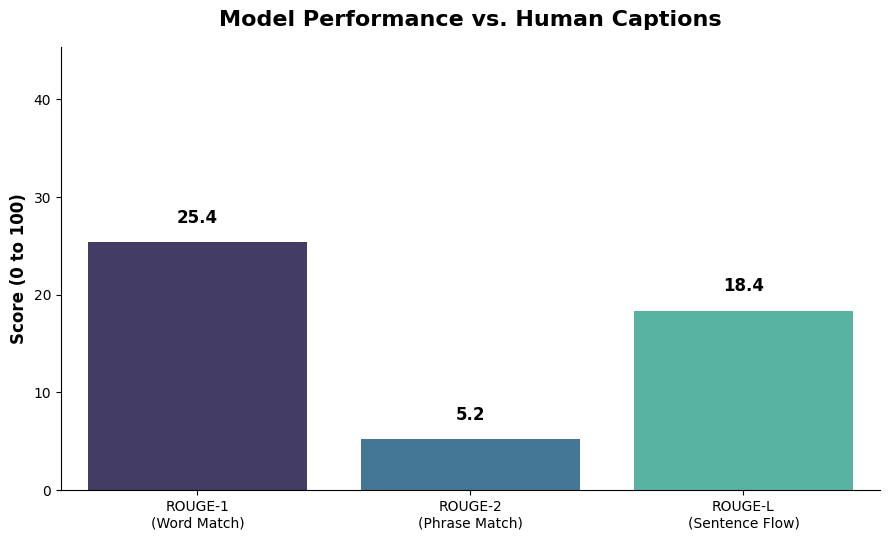


SAMPLE GENERATIONS

🎥 VIDEO 1
True Caption: There are several people gathered in a skating park with skateboards. There a young man wearing a red hat talking about a skateboarding event at Red Bull skate Arcade. Several spectators are gathered in the arcade along with a panel of judges. Some of the participants are beating the heat by splashing water on themselves. The participants begin their stunts on the skateboards as they go over ramps and steep slopes. Several participants are showing off their stunts as spectators cheer and clap for them. They show off their scary yet impressive stunts as the climb up walls and steep ramps without falling. The crowds cheer for them and applaud them. The winners are awarded certificates and prizes for winning.
 Model Output: A man in a red shirt and blue pants is shown riding on a skateboard. He then does a trick by jumping into the air and spinning around, landing back on the skateboard.

🎥 VIDEO 2
True Caption: Cake chemistry explaining how to

In [11]:
import torch
import evaluate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# ==========================================
# 1. LOAD THE BASE MODEL TO GPU
# ==========================================
print("1. Loading base model to GPU...")
model_id = "Qwen/Qwen2.5-7B-Instruct"

# 4-bit config safe for the free T4 GPU
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"": 0}          # Forces model to GPU
)

# ==========================================
# 2. ATTACH SAVED MODEL
# ==========================================
print("2. Attaching trained LoRA weights...")
# Ensure this path matches exactly where your checkpoint is saved!
checkpoint_path = f"{DRIVE_DIR}/video_caption_model"

model = PeftModel.from_pretrained(base_model, checkpoint_path)
model.eval() # Put model strictly in test/read-only mode

# ==========================================
# 3. SETUP THE TEST DATAFRAME
# ==========================================
print("\n3. Prepping evaluation data...")
DESCRIPTION_COLUMN = "input"
TARGET_COLUMN = "target_caption"

# Sampling 50 videos for a quick test. Remove .sample(50) to run all 309
test_df = train_data_test.sample(50, random_state=42)
rouge = evaluate.load('rouge')

predictions = []
references = []

# ==========================================
# 4. GENERATE CAPTIONS
# ==========================================
print(f"Generating captions for {len(test_df)} videos...")

for index, row in tqdm(test_df.iterrows(), total=len(test_df)):

    prompt = (
        "Below is a sequence of frame descriptions from a video. "
        "Write a cohesive caption summarizing the action.\n\n"
        f"### Descriptions:\n{row[DESCRIPTION_COLUMN]}\n\n"
        f"### Caption:\n"
    )

    # Tokenize the text
    inputs = tokenizer(prompt, return_tensors="pt")

    # Force every tensor in the dictionary to the exact same GPU as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=50, temperature=0.7)

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_caption = result.split("### Caption:\n")[-1].strip()

    predictions.append(generated_caption)
    references.append(row[TARGET_COLUMN])

# ==========================================
# 5. SCORE AND PLOT THE CHART
# ==========================================
print("\n4. Calculating ROUGE metrics...")
results = rouge.compute(predictions=predictions, references=references)

scores = [
    results['rouge1'] * 100,
    results['rouge2'] * 100,
    results['rougeL'] * 100
]
labels = ['ROUGE-1\n(Word Match)', 'ROUGE-2\n(Phrase Match)', 'ROUGE-L\n(Sentence Flow)']

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(x=labels, y=scores, palette="mako")

plt.title("Model Performance vs. Human Captions", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score (0 to 100)", fontsize=12, fontweight='bold')
plt.ylim(0, max(scores) + 20)

for i, v in enumerate(scores):
    ax.text(i, v + 2, f"{v:.1f}", ha='center', fontweight='bold', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("SAMPLE GENERATIONS")
print("="*50)
for i in range(3):
    print(f"\n🎥 VIDEO {i+1}")
    print(f"True Caption: {references[i]}")
    print(f" Model Output: {predictions[i]}")

#### Save Qwen predictions

In [ ]:
import pandas as pd
import json

# Save predictions and references to Drive
qwen_predictions_df = pd.DataFrame({
    'video_id': test_df['video_id'].tolist(),
    'segment_index': test_df['segment_index'].tolist(),
    'reference': references,
    'qwen_prediction': predictions,
})
qwen_predictions_df.to_csv(f"{DRIVE_DIR}/qwen_predictions.csv", index=False)

# Save ROUGE scores
qwen_scores = {
    'qwen_finetuned': {k: float(v) for k, v in results.items()}
}

# Append to existing scores file if it exists
import os
scores_path = f"{DRIVE_DIR}/all_scores.json"
if os.path.exists(scores_path):
    with open(scores_path) as f:
        existing = json.load(f)
    existing.update(qwen_scores)
    qwen_scores = existing

with open(scores_path, "w") as f:
    json.dump(qwen_scores, f, indent=2)

print(f"Saved {len(qwen_predictions_df)} Qwen predictions to qwen_predictions.csv")
print(f"Saved Qwen ROUGE scores to all_scores.json")
print(f"\nQwen scores:")
for k, v in qwen_scores['qwen_finetuned'].items():
    print(f"  {k}: {v*100:.2f}")

Saved 50 Qwen predictions to qwen_predictions.csv
Saved Qwen ROUGE scores to all_scores.json

Qwen scores:
  rouge1: 26.03
  rouge2: 4.49
  rougeL: 19.35
  rougeLsum: 19.34


### Qwen BERTscore EVAL

In [8]:
!pip install bert_score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.4 MB/s eta 0:00:00


In [9]:
from bert_score import score as bert_score
import numpy as np

In [12]:
# BERTScore measures semantic similarity using contextual embeddings.
# Unlike ROUGE (which counts overlapping words), BERTScore rewards captions that mean the same thing even if they use different words.

print("Computing BERTScore")

qwen_df = pd.read_csv(f"{DRIVE_DIR}/qwen_predictions.csv")
predictions = qwen_df['qwen_prediction'].tolist()
references = qwen_df['reference'].tolist()

P, R, F1 = bert_score(
    predictions,
    references,
    lang="en",
    verbose=True,
    device="cuda",
    rescale_with_baseline=True,   # makes scores more interpretable
)

# Convert to numpy for easier handling
bertscore_precision = P.cpu().numpy()
bertscore_recall = R.cpu().numpy()
bertscore_f1 = F1.cpu().numpy()

print(f"\n{'='*50}")
print(f"BERTScore Results (mean across {len(predictions)} examples)")
print(f"{'='*50}")
print(f"Precision : {bertscore_precision.mean() * 100:.2f}")
print(f"Recall    : {bertscore_recall.mean() * 100:.2f}")
print(f"F1        : {bertscore_f1.mean() * 100:.2f}")

Computing BERTScore


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 1.79 seconds, 27.99 sentences/sec

BERTScore Results (mean across 50 examples)
Precision : 29.40
Recall    : 19.52
F1        : 24.46


/tmp/ipykernel_41135/3523841862.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=all_labels, y=all_scores, palette="mako")


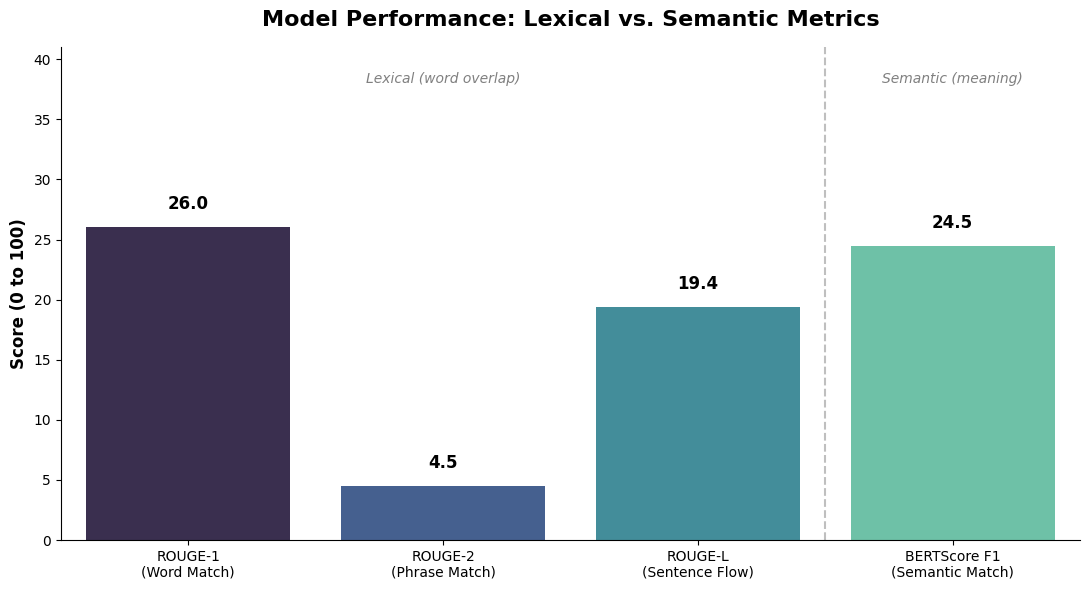

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine ROUGE and BERTScore in one chart
all_scores = [
    results['rouge1'] * 100,
    results['rouge2'] * 100,
    results['rougeL'] * 100,
    bertscore_f1.mean() * 100,
]
all_labels = [
    'ROUGE-1\n(Word Match)',
    'ROUGE-2\n(Phrase Match)',
    'ROUGE-L\n(Sentence Flow)',
    'BERTScore F1\n(Semantic Match)',
]

plt.figure(figsize=(11, 6))
ax = sns.barplot(x=all_labels, y=all_scores, palette="mako")

plt.title("Model Performance: Lexical vs. Semantic Metrics",
          fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score (0 to 100)", fontsize=12, fontweight='bold')
plt.ylim(0, max(all_scores) + 15)

for i, v in enumerate(all_scores):
    ax.text(i, v + 1.5, f"{v:.1f}", ha='center', fontweight='bold', fontsize=12)

# Visual divider between ROUGE and BERTScore
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5)
ax.text(1, max(all_scores) + 12, 'Lexical (word overlap)',
        ha='center', fontsize=10, style='italic', color='gray')
ax.text(3, max(all_scores) + 12, 'Semantic (meaning)',
        ha='center', fontsize=10, style='italic', color='gray')

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Compute per-example ROUGE-L for comparison with per-example BERTScore
per_example_rouge_l = []
for pred, ref in zip(predictions, references):
    r = rouge.compute(predictions=[pred], references=[ref])
    per_example_rouge_l.append(r['rougeL'] * 100)

comparison = pd.DataFrame({
    'prediction': predictions,
    'reference': references,
    'rouge_l': per_example_rouge_l,
    'bertscore_f1': bertscore_f1 * 100,
})

print("=== Correlation between ROUGE-L and BERTScore ===")
print(comparison[['rouge_l', 'bertscore_f1']].corr())
print("\n(Lower correlation = the metrics measure genuinely different things)")

# Show 3 examples where ROUGE is low but BERTScore is high
# (model said the right thing in different words)
comparison['gap'] = comparison['bertscore_f1'] - comparison['rouge_l']
print("\n" + "="*70)
print("EXAMPLES WHERE ROUGE UNDERRATES THE MODEL")
print("(low ROUGE but high BERTScore — semantically correct, lexically different)")
print("="*70)
for _, row in comparison.nlargest(3, 'gap').iterrows():
    print(f"\nReference  : {row['reference']}")
    print(f"Prediction : {row['prediction']}")
    print(f"ROUGE-L    : {row['rouge_l']:.1f}   BERTScore: {row['bertscore_f1']:.1f}")

=== Correlation between ROUGE-L and BERTScore ===
               rouge_l  bertscore_f1
rouge_l       1.000000      0.605156
bertscore_f1  0.605156      1.000000

(Lower correlation = the metrics measure genuinely different things)

EXAMPLES WHERE ROUGE UNDERRATES THE MODEL
(low ROUGE but high BERTScore — semantically correct, lexically different)

Reference  : A person is seen cutting up various fruits while also seen speaking to the camera. The person mixes various ingredients into a container of water. The person spins around the container in the end.
Prediction : A man and woman are shown talking in a kitchen. The man pours a bottle of water into a glass. He then drinks from the glass while holding it up.
ROUGE-L    : 18.8   BERTScore: 43.8

Reference  : Several percussionists stand on a field. They march in place on the field. They are drumming in sync. A woman walks by with a video camera.
Prediction : A man and woman are walking down the street holding drumsticks. They begin play

## Implementing another LLM: Llama -3.1-8B-Instruct

In [13]:
import gc
import torch

# Free any previous models
for var_name in ['model', 'base_model', 'mistral_model']:
    if var_name in dir():
        try:
            exec(f"del {var_name}")
        except NameError:
            pass

gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"GPU memory reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB")

GPU memory allocated: 0.01 GB
GPU memory reserved : 5.45 GB


Baseline Llama with no fine-tuning or prompting

In [ ]:
from tqdm import tqdm

DESCRIPTION_COLUMN = "input"
TARGET_COLUMN = "target_caption"

# Llama 3.1 needs both EOT and EOS as terminators
llama_terminators = [
    llama_tokenizer.eos_token_id,
    llama_tokenizer.convert_tokens_to_ids("<|eot_id|>"),
]

llama_predictions = []
llama_references = []

print(f"Generating captions with Llama for {len(test_df)} videos...")

for index, row in tqdm(test_df.iterrows(), total=len(test_df)):

    prompt = (
        "Below is a sequence of frame descriptions from a video. "
        "Write a cohesive caption summarizing the action.\n\n"
        f"### Descriptions:\n{row[DESCRIPTION_COLUMN]}\n\n"
        f"### Caption:\n"
    )

    inputs = llama_tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(llama_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = llama_model.generate(
            **inputs,
            max_new_tokens=50,
            temperature=0.7,
            do_sample=True,
            eos_token_id=llama_terminators,
            pad_token_id=llama_tokenizer.eos_token_id,
        )

    result = llama_tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated = result.split("### Caption:\n")[-1].strip()

    # Llama sometimes keeps generating past the caption — cut at first newline
    generated = generated.split("\n")[0].strip()

    llama_predictions.append(generated)
    llama_references.append(row[TARGET_COLUMN])

print(f"\nDone. Generated {len(llama_predictions)} captions.")
print("\n--- Sample outputs ---")
for i in range(3):
    print(f"\nReference : {llama_references[i]}")
    print(f"Llama     : {llama_predictions[i]}")

Generating captions with Llama for 50 videos...



  0%|          | 0/50 [00:00<?, ?it/s][transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.

100%|██████████| 50/50 [03:56<00:00,  4.72s/it]


Done. Generated 50 captions.

--- Sample outputs ---

Reference : There are several people gathered in a skating park with skateboards. There a young man wearing a red hat talking about a skateboarding event at Red Bull skate Arcade. Several spectators are gathered in the arcade along with a panel of judges. Some of the participants are beating the heat by splashing water on themselves. The participants begin their stunts on the skateboards as they go over ramps and steep slopes. Several participants are showing off their stunts as spectators cheer and clap for them. They show off their scary yet impressive stunts as the climb up walls and steep ramps without falling. The crowds cheer for them and applaud them. The winners are awarded certificates and prizes for winning.
Llama     : "Thrill-seekers unite! Catch the excitement as a group of fearless skateboarders take to the streets and a local skate park, showcasing their skills and style. From daring tricks and ramps to casual cruise

In [ ]:
import numpy as np
qwen_lens = [len(p.split()) for p in predictions]
llama_lens = [len(p.split()) for p in llama_predictions]
print(f"Qwen avg length:  {np.mean(qwen_lens):.1f} words")
print(f"Llama avg length: {np.mean(llama_lens):.1f} words")

# Look at 3 Llama outputs
for i in range(3):
    print(f"\nLlama [{i}]: {llama_predictions[i]}")

Qwen avg length:  35.3 words
Llama avg length: 42.3 words

Llama [0]: "Thrill-seekers unite! Catch the excitement as a group of fearless skateboarders take to the streets and a local skate park, showcasing their skills and style. From daring tricks and ramps to casual cruises, these skaters are not just

Llama [1]: As the morning light pours into the kitchen, a couple begins their day by standing in the cozy space. The kitchen is filled with warmth and the scent of freshly baked goods. Nearby, a beautiful blue and white painting adorns the wall, adding a

Llama [2]: A day in the life of a bustling city is captured in this sequence of frames. The video begins with a professional conversation between two individuals, setting a formal tone. As the scene shifts, we see a vibrant outdoor event unfolding, with people engaging in


### Training LORA on Llama

In [ ]:
import gc
import torch

# Free zero-shot Llama and any other models
for var_name in ['llama_model', 'model', 'base_model', 'mistral_model']:
    if var_name in dir():
        try:
            exec(f"del {var_name}")
        except NameError:
            pass

gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"GPU memory reserved : {torch.cuda.memory_reserved() / 1e9:.2f} GB")

GPU memory allocated: 4.42 GB
GPU memory reserved : 11.12 GB


In [ ]:
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
from datasets import Dataset

llama_model_id = "meta-llama/Llama-3.1-8B-Instruct"

# 1. Load base in 4-bit
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

llama_train_tokenizer = AutoTokenizer.from_pretrained(llama_model_id)
llama_train_tokenizer.pad_token = llama_train_tokenizer.eos_token
llama_train_tokenizer.padding_side = "right"

llama_base_for_training = AutoModelForCausalLM.from_pretrained(
    llama_model_id,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"": 0},
)
llama_base_for_training = prepare_model_for_kbit_training(llama_base_for_training)

# 2. LoRA config — same as Qwen used
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
llama_for_training = get_peft_model(llama_base_for_training, lora_config)
llama_for_training.print_trainable_parameters()

# 3. Format training data — same template as Qwen
def format_instruction(row):
    return (
        "Below is a sequence of frame descriptions from a video. "
        "Write a cohesive caption summarizing the action.\n\n"
        f"### Descriptions:\n{row['input']}\n\n"
        f"### Caption:\n{row['target_caption']}"
    )

df_train = train_data_train.copy()
df_train['text'] = df_train.apply(format_instruction, axis=1)
train_dataset = Dataset.from_pandas(df_train[['text']])

# 4. Training config — same as Qwen
training_args = SFTConfig(
    output_dir=f"{DRIVE_DIR}/llama_caption_checkpoints",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    num_train_epochs=3,
    logging_steps=10,
    optim="paged_adamw_32bit",
    save_strategy="epoch",
    bf16=False,
    fp16=False,
    report_to="none",
    dataset_text_field="text",
    max_length=512,
)

trainer = SFTTrainer(
    model=llama_for_training,
    train_dataset=train_dataset,
    args=training_args,
)

print("Starting Llama LoRA training...")
trainer.train()

# 5. Save the adapter to Drive
llama_for_training.save_pretrained(f"{DRIVE_DIR}/llama_caption_model")
print(f"\n✓ Saved Llama LoRA adapter to {DRIVE_DIR}/llama_caption_model")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

trainable params: 13,631,488 || all params: 8,043,892,736 || trainable%: 0.1695


Adding EOS to train dataset:   0%|          | 0/1196 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1196 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Starting Llama LoRA training...


Step,Training Loss
10,2.214585
20,1.619454
30,1.539765
40,1.453152
50,1.465625
60,1.439227
70,1.360481
80,1.373873


Step,Training Loss
10,2.214585
20,1.619454
30,1.539765
40,1.453152
50,1.465625
60,1.439227
70,1.360481
80,1.373873
90,1.371926
100,1.319443



✓ Saved Llama LoRA adapter to /content/drive/MyDrive/242B Group Project/llama_caption_model


In [ ]:
import gc, torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# Free the training model
try:
    del trainer
    del llama_for_training
    del llama_base_for_training
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

# Reload base + apply trained adapter
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

llama_tokenizer_ft = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")
llama_tokenizer_ft.pad_token = llama_tokenizer_ft.eos_token

llama_base_inf = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.1-8B-Instruct",
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"": 0},
)
llama_finetuned = PeftModel.from_pretrained(
    llama_base_inf,
    f"{DRIVE_DIR}/llama_caption_model"
)
llama_finetuned.eval()
print("Fine-tuned Llama loaded ✓")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Fine-tuned Llama loaded ✓


In [ ]:
from tqdm import tqdm

llama_terminators = [
    llama_tokenizer_ft.eos_token_id,
    llama_tokenizer_ft.convert_tokens_to_ids("<|eot_id|>"),
]

llama_ft_predictions = []

print(f"Generating fine-tuned Llama captions for {len(test_df)} videos...")

for index, row in tqdm(test_df.iterrows(), total=len(test_df)):
    prompt = (
        "Below is a sequence of frame descriptions from a video. "
        "Write a cohesive caption summarizing the action.\n\n"
        f"### Descriptions:\n{row['input']}\n\n"
        f"### Caption:\n"
    )

    inputs = llama_tokenizer_ft(prompt, return_tensors="pt")
    inputs = {k: v.to(llama_finetuned.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = llama_finetuned.generate(
            **inputs,
            max_new_tokens=50,
            temperature=0.7,
            do_sample=True,
            eos_token_id=llama_terminators,
            pad_token_id=llama_tokenizer_ft.eos_token_id,
        )

    input_length = inputs['input_ids'].shape[1]
    generated_tokens = outputs[0][input_length:]
    generated = llama_tokenizer_ft.decode(generated_tokens, skip_special_tokens=True)
    generated = generated.split("\n")[0].strip()

    llama_ft_predictions.append(generated)

print(f"\nDone. Sample outputs:")
for i in range(3):
    print(f"\nReference        : {references[i]}")
    # print(f"Llama (zero-shot): {llama_predictions[i]}")
    print(f"Llama (fine-tuned): {llama_ft_predictions[i]}")

Generating fine-tuned Llama captions for 50 videos...


100%|██████████| 50/50 [04:37<00:00,  5.55s/it]


Done. Sample outputs:

Reference        : There are several people gathered in a skating park with skateboards. There a young man wearing a red hat talking about a skateboarding event at Red Bull skate Arcade. Several spectators are gathered in the arcade along with a panel of judges. Some of the participants are beating the heat by splashing water on themselves. The participants begin their stunts on the skateboards as they go over ramps and steep slopes. Several participants are showing off their stunts as spectators cheer and clap for them. They show off their scary yet impressive stunts as the climb up walls and steep ramps without falling. The crowds cheer for them and applaud them. The winners are awarded certificates and prizes for winning.
Llama (fine-tuned): A group of people are standing in a park. One of the people is doing tricks on a skateboard. The person does a trick on the skateboard and falls on his back.

Reference        : Cake chemistry explaining how to do a at ho

#### Save Llama predictions

In [ ]:
import pandas as pd

llama_ft_df = pd.DataFrame({
    'video_id': test_df['video_id'].tolist(),
    'segment_index': test_df['segment_index'].tolist(),
    'reference': references,  # same references used for all
    'llama_ft_prediction': llama_ft_predictions,
})
llama_ft_df.to_csv(f"{DRIVE_DIR}/llama_ft_predictions.csv", index=False)
print(f"✓ Saved Llama fine-tuned predictions")

✓ Saved Llama fine-tuned predictions


Computing Llama ROUGE + BERTscore

In [ ]:
import evaluate
from bert_score import score as bert_score
import numpy as np

# Make sure rouge is loaded
rouge = evaluate.load('rouge')

print("Computing ROUGE for fine-tuned Llama...")
llama_ft_rouge = rouge.compute(
    predictions=llama_ft_predictions,
    references=references
)

print("Computing BERTScore for fine-tuned Llama...")
P_ft, R_ft, F1_ft = bert_score(
    llama_ft_predictions, references,
    lang="en", verbose=False, device="cuda",
    rescale_with_baseline=True,
)
llama_ft_bertscore_f1 = F1_ft.cpu().numpy()

print(f"\n{'='*50}")
print(f"Llama-3.1-8B-Instruct (FINE-TUNED) Results")
print(f"{'='*50}")
print(f"ROUGE-1      : {llama_ft_rouge['rouge1']*100:.2f}")
print(f"ROUGE-2      : {llama_ft_rouge['rouge2']*100:.2f}")
print(f"ROUGE-L      : {llama_ft_rouge['rougeL']*100:.2f}")
print(f"BERTScore F1 : {llama_ft_bertscore_f1.mean()*100:.2f}")

Computing ROUGE for fine-tuned Llama...
Computing BERTScore for fine-tuned Llama...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Llama-3.1-8B-Instruct (FINE-TUNED) Results
ROUGE-1      : 25.85
ROUGE-2      : 5.27
ROUGE-L      : 19.27
BERTScore F1 : 23.51


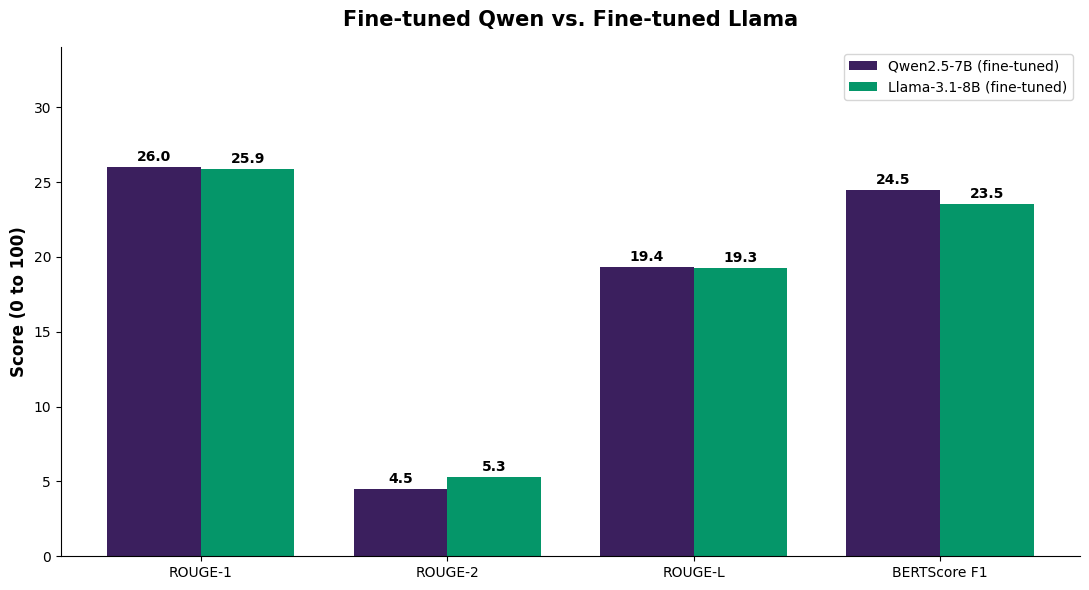

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import json

# Load all scores from Drive
with open(f"{DRIVE_DIR}/all_scores.json") as f:
    all_scores = json.load(f)

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore F1']

qwen_scores = [
    all_scores['qwen_finetuned']['rouge1'] * 100,
    all_scores['qwen_finetuned']['rouge2'] * 100,
    all_scores['qwen_finetuned']['rougeL'] * 100,
    all_scores['qwen_finetuned']['bertscore_f1'] * 100,
]
llama_ft_scores = [
    all_scores['llama_finetuned']['rouge1'] * 100,
    all_scores['llama_finetuned']['rouge2'] * 100,
    all_scores['llama_finetuned']['rougeL'] * 100,
    all_scores['llama_finetuned']['bertscore_f1'] * 100,
]

x = np.arange(len(metrics))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width/2, qwen_scores, width,
            label='Qwen2.5-7B (fine-tuned)', color='#3b1f5e')
b2 = ax.bar(x + width/2, llama_ft_scores, width,
            label='Llama-3.1-8B (fine-tuned)', color='#059669')

ax.set_ylabel('Score (0 to 100)', fontsize=12, fontweight='bold')
ax.set_title('Fine-tuned Qwen vs. Fine-tuned Llama',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='upper right', fontsize=10)

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.1f}', ha='center', fontweight='bold', fontsize=10)

ax.set_ylim(0, max(max(qwen_scores), max(llama_ft_scores)) + 8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
import json

# Append Llama FT scores to the all_scores.json
with open(f"{DRIVE_DIR}/all_scores.json") as f:
    all_scores = json.load(f)

all_scores['llama_finetuned'] = {
    'rouge1': float(llama_ft_rouge['rouge1']),
    'rouge2': float(llama_ft_rouge['rouge2']),
    'rougeL': float(llama_ft_rouge['rougeL']),
    'bertscore_f1': float(llama_ft_bertscore_f1.mean()),
}

with open(f"{DRIVE_DIR}/all_scores.json", "w") as f:
    json.dump(all_scores, f, indent=2)

print("✓ Saved fine-tuned Llama scores to all_scores.json")
print("\nAll scores so far:")
for k, v in all_scores.items():
    print(f"  {k}:")
    for metric, value in v.items():
        print(f"    {metric}: {value*100:.2f}")

✓ Saved fine-tuned Llama scores to all_scores.json

All scores so far:
  qwen_finetuned:
    rouge1: 26.03
    rouge2: 4.49
    rougeL: 19.35
    rougeLsum: 19.34
  llama_finetuned:
    rouge1: 25.85
    rouge2: 5.27
    rougeL: 19.27
    bertscore_f1: 23.51


#### Cloning "frames" folder + "descriptions_test.jsonl" to GDrive

In [ ]:
import os
import shutil

# Clone repo into Colab's local disk
!git clone https://github.com/feifanjasmineguan/video-caption.git /content/repo 2>&1 | tail -2

# Copy frames to Drive
src_frames = "/content/repo/output/frames"
dst_frames = f"{DRIVE_DIR}/frames"
if not os.path.exists(dst_frames):
    print("Copying frames to Drive (~221 MB, takes 3-5 min)...")
    shutil.copytree(src_frames, dst_frames)
    print("✓ Frames done")

# Copy descriptions_test.jsonl to Drive
shutil.copy("/content/repo/output/descriptions_test.jsonl",
            f"{DRIVE_DIR}/descriptions_test.jsonl")
print("✓ JSONL done")

# Verify
n_videos = len(os.listdir(f"{DRIVE_DIR}/frames"))
print(f"\nDrive now has {n_videos} video folders + descriptions_test.jsonl")

Cloning into '/content/repo'...
Updating files: 100% (6899/6899), done.
Copying frames to Drive (~221 MB, takes 3-5 min)...
✓ Frames done
✓ JSONL done

Drive now has 388 video folders + descriptions_test.jsonl


## CLIPscore for image-text comparison

In [ ]:
import gc
import torch

# Free everything from earlier experiments
for var_name in ['model', 'base_model', 'llama_finetuned', 'llama_base_inf',
                 'llama_model', 'llama_for_training', 'llama_base_for_training',
                 'mistral_model', 'trainer']:
    if var_name in dir():
        try:
            exec(f"del {var_name}")
        except NameError:
            pass

gc.collect()
torch.cuda.empty_cache()

print(f"GPU allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

GPU allocated: 0.02 GB


In [ ]:
!pip install open_clip_torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00


In [ ]:
import open_clip
import torch

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')
clip_model = clip_model.to('cuda').eval()

print("✓ CLIP loaded")
print(f"GPU allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✓ CLIP loaded
GPU allocated: 0.62 GB


In [ ]:
import json
import os

frame_paths_lookup = {}
with open(f"{DRIVE_DIR}/descriptions_test.jsonl") as f:
    for line in f:
        entry = json.loads(line)
        for seg in entry["segments"]:
            key = (entry["video_id"], seg["segment_index"])
            # Translate "output/frames/..." paths to Drive paths
            local_paths = [
                p.replace("output/frames", f"{DRIVE_DIR}/frames")
                for p in seg["frame_paths"]
            ]
            frame_paths_lookup[key] = local_paths

print(f"✓ Built lookup for {len(frame_paths_lookup)} segments")

# Test that a frame actually exists
sample_key = list(frame_paths_lookup.keys())[0]
sample_path = frame_paths_lookup[sample_key][0]
print(f"\nSample lookup:")
print(f"  Key: {sample_key}")
print(f"  First frame: {sample_path}")
print(f"  Exists: {os.path.exists(sample_path)}")

✓ Built lookup for 305 segments

Sample lookup:
  Key: ('v_ikZwamRM5mo', 0)
  First frame: /content/drive/MyDrive/242B Group Project/frames/v_ikZwamRM5mo/seg_000/frame_000.jpg
  Exists: True


In [ ]:
import torch
from PIL import Image
import numpy as np

def clip_score(caption, frame_paths):
    """Mean cosine similarity between caption and each frame in the segment."""
    if not frame_paths:
        return None

    # Encode the caption
    text_tokens = clip_tokenizer([caption]).to('cuda')
    with torch.no_grad():
        text_emb = clip_model.encode_text(text_tokens)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)

    # Encode each frame and compute similarity
    sims = []
    for fp in frame_paths:
        if not os.path.exists(fp):
            continue
        try:
            img = Image.open(fp).convert("RGB")
            img_tensor = clip_preprocess(img).unsqueeze(0).to('cuda')
            with torch.no_grad():
                img_emb = clip_model.encode_image(img_tensor)
                img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
            sims.append((text_emb @ img_emb.T).item())
        except Exception as e:
            print(f"Skipping {fp}: {e}")

    return np.mean(sims) if sims else None

print("✓ clip_score function defined")

✓ clip_score function defined


In [ ]:
import pandas as pd

# Load saved predictions
qwen_df = pd.read_csv(f"{DRIVE_DIR}/qwen_predictions.csv")
llama_ft_df = pd.read_csv(f"{DRIVE_DIR}/llama_ft_predictions.csv")

# Sanity check: same video order
assert qwen_df['video_id'].tolist() == llama_ft_df['video_id'].tolist(), \
    "MISMATCH — DataFrames have different video orders!"

# Pull arrays out
test_video_ids = qwen_df['video_id'].tolist()
test_segment_indices = qwen_df['segment_index'].tolist()
references = qwen_df['reference'].tolist()
qwen_predictions = qwen_df['qwen_prediction'].tolist()
llama_ft_predictions = llama_ft_df['llama_ft_prediction'].tolist()

print(f"✓ Loaded {len(qwen_predictions)} segments from each model")
print(f"  First video_id: {test_video_ids[0]}")
print(f"  First segment_index: {test_segment_indices[0]}")

✓ Loaded 50 segments from each model
  First video_id: v_UUjXw1xjprU
  First segment_index: 1


In [ ]:
from tqdm import tqdm
import numpy as np

def score_all(captions_list, label):
    """Run clip_score on every (video_id, segment_index, caption) triple."""
    print(f"\nScoring {label}...")
    scores = []
    for vid, seg, cap in tqdm(zip(test_video_ids, test_segment_indices, captions_list),
                                total=len(captions_list)):
        frames = frame_paths_lookup.get((vid, seg), [])
        scores.append(clip_score(cap, frames))
    return scores

clip_qwen = score_all(qwen_predictions, "Qwen (fine-tuned)")
clip_llama_ft = score_all(llama_ft_predictions, "Llama (fine-tuned)")
clip_reference = score_all(references, "Reference (ceiling)")

# Filter out any None values (failed segments) and convert to arrays
def clean(scores):
    return np.array([s for s in scores if s is not None])

clip_qwen_arr = clean(clip_qwen)
clip_llama_ft_arr = clean(clip_llama_ft)
clip_reference_arr = clean(clip_reference)

print(f"\n{'='*55}")
print(f"CLIP Scores (cosine similarity, x100)")
print(f"{'='*55}")
print(f"Reference (ceiling)    : {clip_reference_arr.mean()*100:.2f}")
print(f"Qwen (fine-tuned)      : {clip_qwen_arr.mean()*100:.2f}")
print(f"Llama (fine-tuned)     : {clip_llama_ft_arr.mean()*100:.2f}")
print(f"\nValid scores: Qwen={len(clip_qwen_arr)}, Llama-FT={len(clip_llama_ft_arr)}, Ref={len(clip_reference_arr)}")


Scoring Qwen (fine-tuned)...


100%|██████████| 50/50 [00:05<00:00,  8.36it/s]



Scoring Llama (fine-tuned)...


100%|██████████| 50/50 [00:04<00:00, 10.28it/s]



Scoring Reference (ceiling)...


100%|██████████| 50/50 [00:04<00:00, 10.35it/s]


CLIP Scores (cosine similarity, x100)
Reference (ceiling)    : 26.24
Qwen (fine-tuned)      : 24.46
Llama (fine-tuned)     : 24.66

Valid scores: Qwen=50, Llama-FT=50, Ref=50


In [ ]:
import json
import numpy as np

# Save per-example arrays
np.save(f"{DRIVE_DIR}/clip_qwen.npy", clip_qwen_arr)
np.save(f"{DRIVE_DIR}/clip_llama_ft.npy", clip_llama_ft_arr)
np.save(f"{DRIVE_DIR}/clip_reference.npy", clip_reference_arr)

# Append to all_scores.json
with open(f"{DRIVE_DIR}/all_scores.json") as f:
    all_scores = json.load(f)

all_scores['qwen_finetuned']['clip_score'] = float(clip_qwen_arr.mean())
all_scores['llama_finetuned']['clip_score'] = float(clip_llama_ft_arr.mean())
all_scores['reference_ceiling'] = {'clip_score': float(clip_reference_arr.mean())}

with open(f"{DRIVE_DIR}/all_scores.json", "w") as f:
    json.dump(all_scores, f, indent=2)

print("✓ Saved CLIP scores to Drive")

✓ Saved CLIP scores to Drive


#### 20 - 35 range is good

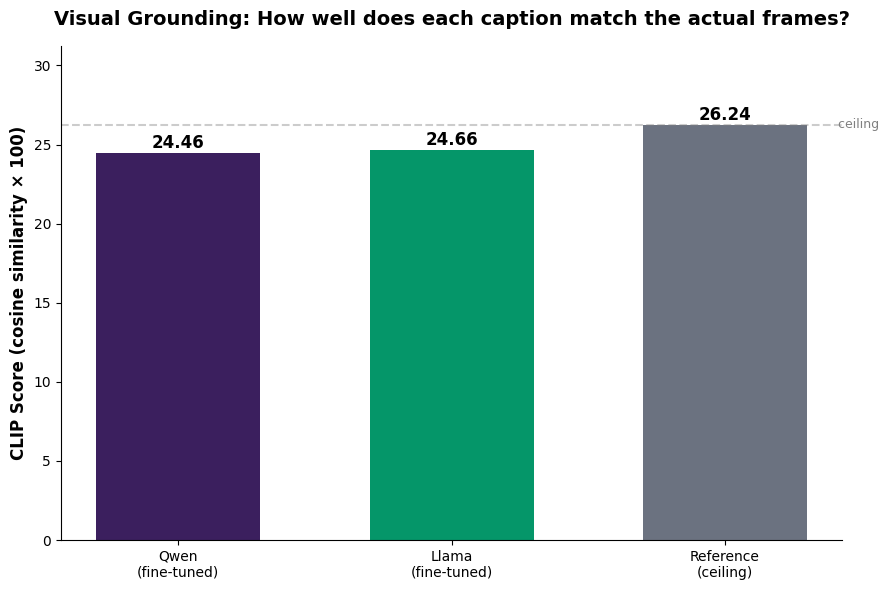

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Qwen\n(fine-tuned)', 'Llama\n(fine-tuned)', 'Reference\n(ceiling)']
scores = [clip_qwen_arr.mean()*100, clip_llama_ft_arr.mean()*100, clip_reference_arr.mean()*100]
colors = ['#3b1f5e', '#059669', '#6b7280']

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(models, scores, color=colors, width=0.6)

ax.set_ylabel('CLIP Score (cosine similarity × 100)', fontsize=12, fontweight='bold')
ax.set_title('Visual Grounding: How well does each caption match the actual frames?',
             fontsize=14, fontweight='bold', pad=15)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
            f'{h:.2f}', ha='center', fontweight='bold', fontsize=12)

ax.set_ylim(0, max(scores) + 5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(y=clip_reference_arr.mean()*100, color='gray', linestyle='--', alpha=0.4)
ax.text(2.4, clip_reference_arr.mean()*100, ' ceiling', va='center', color='gray', fontsize=9)

plt.tight_layout()
plt.show()

### CLIPscore analysis:
- Save the per-segment CLIP scores for qualitative analysis. Looking at the segments where Qwen and Llama scored highest and lowest — see if there's a pattern.

In [ ]:
import pandas as pd
import numpy as np

# Combine everything into one DataFrame
analysis_df = pd.DataFrame({
    'video_id': test_video_ids,
    'segment_index': test_segment_indices,
    'reference': references,
    'qwen_pred': qwen_predictions,
    'llama_ft_pred': llama_ft_predictions,
    'clip_qwen': clip_qwen,
    'clip_llama_ft': clip_llama_ft,
    'clip_reference': clip_reference,
})

# Drop rows where any CLIP score failed (None)
analysis_df = analysis_df.dropna(subset=['clip_qwen', 'clip_llama_ft', 'clip_reference'])

# Convert CLIP scores to ×100 for readability
for col in ['clip_qwen', 'clip_llama_ft', 'clip_reference']:
    analysis_df[col] = analysis_df[col] * 100

# Add useful derived columns
analysis_df['qwen_gap'] = analysis_df['clip_qwen'] - analysis_df['clip_reference']
analysis_df['llama_gap'] = analysis_df['clip_llama_ft'] - analysis_df['clip_reference']
analysis_df['model_diff'] = analysis_df['clip_qwen'] - analysis_df['clip_llama_ft']

print(f"Analysis on {len(analysis_df)} segments")
print(f"\nMean CLIP scores:")
print(f"  Qwen      : {analysis_df['clip_qwen'].mean():.2f}")
print(f"  Llama-FT  : {analysis_df['clip_llama_ft'].mean():.2f}")
print(f"  Reference : {analysis_df['clip_reference'].mean():.2f}")

# Save for posterity
analysis_df.to_csv(f"{DRIVE_DIR}/clip_analysis.csv", index=False)
print(f"\n✓ Saved to clip_analysis.csv")

Analysis on 50 segments

Mean CLIP scores:
  Qwen      : 24.46
  Llama-FT  : 24.66
  Reference : 26.24

✓ Saved to clip_analysis.csv


Segments with worst performance

In [ ]:
# Average the two models' CLIP scores, then find the biggest gap from reference
analysis_df['avg_model_clip'] = (analysis_df['clip_qwen'] + analysis_df['clip_llama_ft']) / 2
analysis_df['avg_gap'] = analysis_df['avg_model_clip'] - analysis_df['clip_reference']

print("="*70)
print("WORST GROUNDING — both models score far below reference")
print("(Likely hallucinations or generic captions)")
print("="*70)

worst = analysis_df.nsmallest(5, 'avg_gap')
for _, row in worst.iterrows():
    print(f"\n[{row['video_id']} seg {row['segment_index']}]")
    print(f"  Reference  ({row['clip_reference']:.1f}): {row['reference']}")
    print(f"  Qwen       ({row['clip_qwen']:.1f}): {row['qwen_pred']}")
    print(f"  Llama-FT   ({row['clip_llama_ft']:.1f}): {row['llama_ft_pred']}")
    print(f"  Gap from reference: {row['avg_gap']:.1f}")

WORST GROUNDING — both models score far below reference
(Likely hallucinations or generic captions)

[v_-G8N5FxjZbw seg 0]
  Reference  (32.1): A man is seen playing a set of bagpipes while people behind him push around bicycles. He is seen playing again while more people walk in and out of frame with children and dogs. Some people stop to hear him play and he stops to look to the camera.
  Qwen       (19.4): A group of men are shown in a field. They are playing a game with sticks and balls. They continue to play for a while.
  Llama-FT   (18.3): A person is seen walking on the sidewalk with a bike. The person is seen riding the bike on a road. The person is seen riding the bike on a sidewalk. The person is seen riding the bike on a road.
  Gap from reference: -13.2

[v_-G8N5FxjZbw seg 2]
  Reference  (32.3): A man is seen playing a set of bagpipes while people behind him push around bicycles. He is seen playing again while more people walk in and out of frame with children and dogs. S

Segments with best performance

In [ ]:
print("="*70)
print("WHERE MODELS BEAT THE REFERENCE")
print("(Models more literal/visual than the human caption)")
print("="*70)

best = analysis_df.nlargest(5, 'avg_gap')
for _, row in best.iterrows():
    print(f"\n[{row['video_id']} seg {row['segment_index']}]")
    print(f"  Reference  ({row['clip_reference']:.1f}): {row['reference']}")
    print(f"  Qwen       ({row['clip_qwen']:.1f}): {row['qwen_pred']}")
    print(f"  Llama-FT   ({row['clip_llama_ft']:.1f}): {row['llama_ft_pred']}")
    print(f"  Gap from reference: +{row['avg_gap']:.1f}")

WHERE MODELS BEAT THE REFERENCE
(Models more literal/visual than the human caption)

[v_OH5UXwa3F7E seg 5]
  Reference  (21.1): We see an opening screen and a man runs and does a high jump at fifteen feet. We see a man jump the high jump on a track at various height with lots of cut scenes. We see seventeen and a still of the man. We see fifteen nine scroll across the screen. We see a series of still of the man and sixteen six. Seventeen two scrolls across the screen. We see seventeen nine scroll across the screen. We then see the ending credits.
  Qwen       (29.5): A person is seen running on a track and the camera zooms in on his legs. The person continues running and the camera pans to show the crowd around him.
  Llama-FT   (28.7): A man stands on the track holding a pole. The man jumps over the pole on the track. The man continues jumping on the track. The man runs off the track.
  Gap from reference: +8.1

[v_fN2DiOswmOA seg 7]
  Reference  (22.8): The screen shows the title of 

Segments where Qwen vs Llama disagree most

In [ ]:
print("="*70)
print("QWEN VS LLAMA — biggest disagreements")
print("="*70)

print("\n--- Qwen scored much higher than Llama ---")
qwen_better = analysis_df.nlargest(3, 'model_diff')
for _, row in qwen_better.iterrows():
    print(f"\n[{row['video_id']} seg {row['segment_index']}]")
    print(f"  Reference  : {row['reference']}")
    print(f"  Qwen   ({row['clip_qwen']:.1f}): {row['qwen_pred']}")
    print(f"  Llama  ({row['clip_llama_ft']:.1f}): {row['llama_ft_pred']}")

print("\n\n--- Llama scored much higher than Qwen ---")
llama_better = analysis_df.nsmallest(3, 'model_diff')
for _, row in llama_better.iterrows():
    print(f"\n[{row['video_id']} seg {row['segment_index']}]")
    print(f"  Reference  : {row['reference']}")
    print(f"  Qwen   ({row['clip_qwen']:.1f}): {row['qwen_pred']}")
    print(f"  Llama  ({row['clip_llama_ft']:.1f}): {row['llama_ft_pred']}")

QWEN VS LLAMA — biggest disagreements

--- Qwen scored much higher than Llama ---

[v_UUjXw1xjprU seg 2]
  Reference  : There are several people gathered in a skating park with skateboards. There a young man wearing a red hat talking about a skateboarding event at Red Bull skate Arcade. Several spectators are gathered in the arcade along with a panel of judges. Some of the participants are beating the heat by splashing water on themselves. The participants begin their stunts on the skateboards as they go over ramps and steep slopes. Several participants are showing off their stunts as spectators cheer and clap for them. They show off their scary yet impressive stunts as the climb up walls and steep ramps without falling. The crowds cheer for them and applaud them. The winners are awarded certificates and prizes for winning.
  Qwen   (26.2): A man is riding his skateboard on an indoor ramp. He does a flip and lands on the ground.
  Llama  (17.6): A group of men are standing in a field. 

Showing worst grounding case:


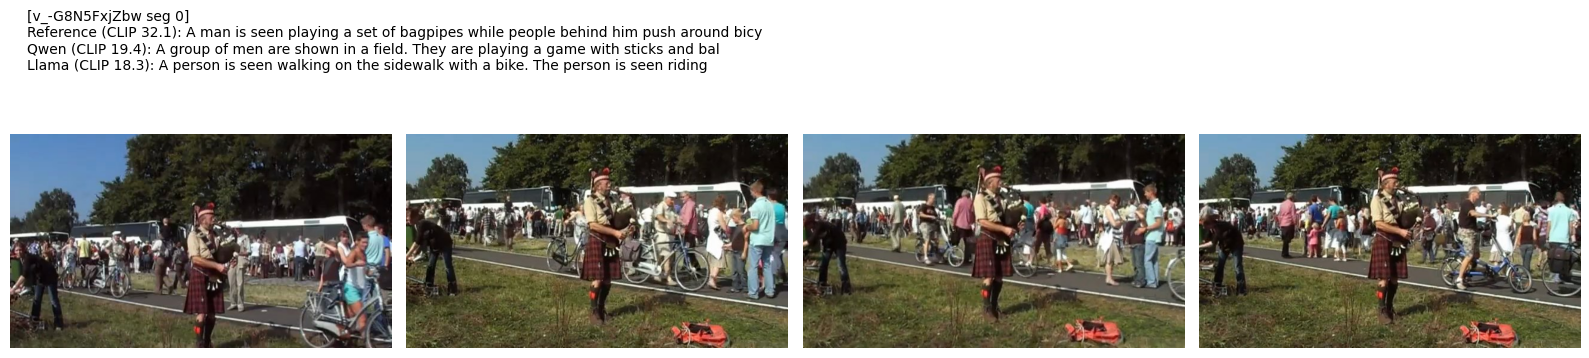

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_segment(video_id, segment_index, max_frames=4):
    """Display frames + all three captions for a single segment."""
    row = analysis_df[
        (analysis_df['video_id'] == video_id) &
        (analysis_df['segment_index'] == segment_index)
    ]
    if len(row) == 0:
        print(f"Segment {video_id}/{segment_index} not in analysis_df")
        return
    row = row.iloc[0]

    frame_paths = frame_paths_lookup.get((video_id, segment_index), [])[:max_frames]
    n = len(frame_paths)

    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]
    for ax, fp in zip(axes, frame_paths):
        if os.path.exists(fp):
            ax.imshow(Image.open(fp))
        ax.axis('off')

    title = f"[{video_id} seg {segment_index}]\n"
    title += f"Reference (CLIP {row['clip_reference']:.1f}): {row['reference'][:80]}\n"
    title += f"Qwen (CLIP {row['clip_qwen']:.1f}): {row['qwen_pred'][:80]}\n"
    title += f"Llama (CLIP {row['clip_llama_ft']:.1f}): {row['llama_ft_pred'][:80]}"
    plt.suptitle(title, fontsize=10, ha='left', x=0.02, y=0.98)
    plt.tight_layout()
    plt.show()

worst_row = analysis_df.nsmallest(1, 'avg_gap').iloc[0]
print(f"Showing worst grounding case:")
show_segment(worst_row['video_id'], worst_row['segment_index'])